# Clustering Standard Errors V2
Julian Hsu

30-May-2026

The purpose of this notebook is to show how ignoring clustering inflates your false positive rate. You think of this as the complement to the V1 notebook here: `causalinference_crashcourse\OtherMaterial\General Points about Estimating Treatment Effect Models\Clustering Standard Errors.ipynb`.

**sound byte:**

Using your standard experimentation software can lead to incorrect decisions in non-standard situations. A common one is when you are randomizing at some cluster or segment level: assigning treatment/control regions, cities, or isolated social networks. But then you use user-level data. 

If your organization usually does user-randomization, then your standard software will be overly-precise because it assumes the treatment was assigned at the user level. It has ignored that cluster-specific errors are correlated with treatment, meaning that outcomes are noisier than expected. Outcomes can be correlated with treatment status but have nothing to do with treatment. 

With simulation data, I show that you get stat-sig estimates **from a placebo estimate** far too often if you ignore this clustering. You are more likely to think your estimate had an effect when really it was just noise.  Specifically, the false positive rate is larger than 5%. Make sure that your experiment analysis and modeling align with the experiment design!

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

## Data Generating Functions and Estimating Functions

In [5]:
def dgp(n_clusters=200, n_per_cluster=50, impact=0):
    df_cluster = pd.DataFrame({
        'cluster_id': np.arange(n_clusters),
        'w': np.random.choice(2, n_clusters),
        'gp_err': np.random.normal(0, 0.5, n_clusters)
    })

    df = pd.DataFrame({
        'cluster_id': np.repeat(np.arange(n_clusters), n_per_cluster)
    })
    df = df.merge(df_cluster, on='cluster_id')
    df['x'] = np.random.uniform(0, 1, len(df))
    df['y'] = (impact * df['w']
               + df['gp_err']
               + np.random.normal(0, 1, len(df))
               + np.random.uniform(-2, 1) * df['x'])
    return df


def get_pvalue(df, cluster_se=False):
    model = sm.OLS(endog=df['y'], exog=sm.add_constant(df[['w', 'x']]))
    if cluster_se:
        result = model.fit(cov_type='cluster', cov_kwds={'groups': df['cluster_id']})
    else:
        result = model.fit()
    return result.pvalues['w']

## Simulations

Assume that the experiment is randomized at a cluster-level. 
Also, assume the experiment has no impact. Then if we have the correct standard error, only 5% of the time we will find a stat sig estimate.

In [ ]:
np.random.seed(42)
n_sims = 1000
n_clusters = 200
n_per_cluster = 50

results = {'standard_se': [], 'clustered_se': []}

for _ in range(n_sims):
    df = dgp(n_clusters=n_clusters, n_per_cluster=n_per_cluster, impact=0)
    results['standard_se'].append(get_pvalue(df, cluster_se=False))
    results['clustered_se'].append(get_pvalue(df, cluster_se=True))

fpr = {k: np.mean(np.array(v) < 0.05) for k, v in results.items()}
print(f"False Positive Rate (Standard SE): {fpr['standard_se']:.3f}")
print(f"False Positive Rate (Clustered SE): {fpr['clustered_se']:.3f}")

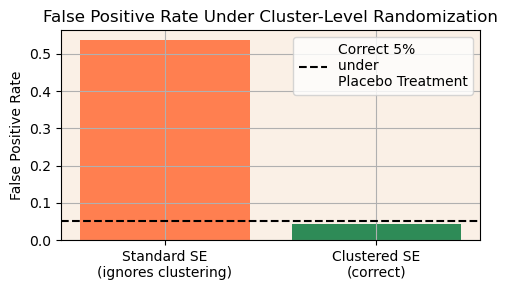

In [9]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 3))

labels = ['Standard SE\n(ignores clustering)', 'Clustered SE\n(correct)']
values = [fpr['standard_se'], fpr['clustered_se']]
colors = ['coral', 'seagreen']

ax.bar(np.arange(2), values, color=colors)
ax.axhline(0.05, color='black', linestyle='--', label='Correct 5% \nunder \nPlacebo Treatment')
ax.set_xticks(np.arange(2))
ax.set_xticklabels(labels)
ax.set_ylabel('False Positive Rate')
ax.set_title('False Positive Rate Under Cluster-Level Randomization')
ax.legend()
ax.grid()
ax.set_facecolor('linen')
plt.tight_layout()
plt.show()